In [ ]:
import pandas as pd
combined_dataframe = pd.read_csv("data/sparsity.csv")
combined_dataframe["P"] = combined_dataframe["N_total"] / combined_dataframe["N_active"]


In [12]:
import autograd.numpy as np
from autograd import grad
from scipy.optimize import minimize

# Custom logsumexp function for numerical stability
def custom_logsumexp(terms):
    max_term = np.max(terms, axis=0)
    sum_exp = np.sum(np.exp(terms - max_term), axis=0)
    return max_term + np.log(sum_exp)

# Modified loss function for fitting log(loss)
def loss_scipy_upcycle(params, inp, loss_type="huber", delta=1e-3):
    a, b, c, d1, E = params
    param_usage, N_active, y = inp[:, 0], inp[:, 1] , inp[:, 2]  # Scale N_active and take log of loss

    # Compute the predicted log loss using the given equation
    term1 = d1  - a * np.log( param_usage) - b * np.log(N_active) + c * np.log(param_usage)* np.log(N_active)
    term3 = E * np.ones_like(param_usage) # use fit from scratch models

    # Use custom_logsumexp for numerical stability
    terms = np.stack([term1, term3], axis=0)
    post_lse = custom_logsumexp(terms)
    
    if loss_type == "huber":
        residual = post_lse - np.log(y)
        loss = np.where(np.abs(residual) <= delta,
                                0.5 * residual**2,
                                delta * (np.abs(residual) - 0.5 * delta)).sum()
    elif loss_type == "msle":
        loss = ((post_lse - np.log(y))**2).sum()
    elif loss_type == "mse":
        loss = ((np.exp(post_lse) - y)**2).sum()
    else:
        raise NotImplementedError(f"loss {loss_type} not implemented!")
    
    return loss 

# Objective function for optimization
def objective_fn(params, inp):
    return loss_scipy_upcycle(params, inp)

# Optimization function using BFGS
from itertools import product
import random

def grid_search_optimize(inp, param_grid, early_stopping_rounds=10):
    min_loss = float('inf')
    best_params = None
    no_improve_rounds = 0

    # Generate all combinations of parameter values
    param_combinations = list(product(
        param_grid['a'], 
        param_grid['b'], 
        param_grid['c'], 
        param_grid['d1'], 
        param_grid['E'], 
    ))
    random.shuffle(param_combinations)

    for params in param_combinations:
        a, b, c, d1, E = params
        init_params = (a, b, c, d1, E)  # For upcycle model

        objective_grad = grad(objective_fn)

        # Run optimization with the Jacobian
        result = minimize(
            objective_fn, 
            init_params, 
            args=inp,
            method='BFGS', 
            jac=objective_grad
        )

        l = result.fun
        optimized_params = result.x

        # Update best params if loss is lower
        if l < min_loss:
            min_loss = l
            best_params = optimized_params
            no_improve_rounds = 0  # Reset early stopping counter
        else:
            no_improve_rounds += 1

        # Check for early stopping
        if no_improve_rounds >= early_stopping_rounds:
            print(f"Early stopping after {early_stopping_rounds} rounds with no improvement.")
            break

    return min_loss, best_params

In [13]:
filter_dataframe = combined_dataframe[
    (combined_dataframe['D1'].sub(2.3068672).abs() < 1e-5) &
    (combined_dataframe['D2'].sub(2.3068672).abs() < 1e-5)
]
inp = filter_dataframe[['P', 'N_active', 'Loss']].values

sorted_array = inp[inp[:, 2].argsort()]
split_index = int(len(inp) * 0)
# sorted_array = inp_merge[inp_merge[:, 2].argsort()]
# split_index = int(len(inp_merge) * 0.2)


param_grid = {
    'a': np.linspace(0, 1, 5),  # 5 equally spaced values between 0 and 1
    'b': np.linspace(0, 1, 5),
    'c': np.linspace(0, 1, 5),
    'd1': np.linspace(-5, 5, 5),
    'E': np.linspace(-5, 5, 5),
}

# Split the array
split_80 = sorted_array[split_index:]  # 80% with higher values in the 4th column
split_20 = sorted_array[:split_index]  # 20% with lowest values in the 4th column
loss_train, params_train = grid_search_optimize(split_80, param_grid=param_grid, early_stopping_rounds=10)
print(loss_train, params_train)

Early stopping after 10 rounds with no improvement.
0.0003163797836510356 [ 0.03279177  0.29711684 -0.00910326 -1.44946975  0.86190213]


## multiplicative with interaction

In [14]:
import autograd.numpy as np
from autograd import grad
from scipy.optimize import minimize
from tqdm import tqdm

def custom_logsumexp(terms):
    max_term = np.max(terms, axis=0)
    sum_exp = np.sum(np.exp(terms - max_term), axis=0)
    return max_term + np.log(sum_exp)


def loss_scipy_upcycle(params, inp, loss_type="huber", delta = 1e-3):
    # a, b, d1 = params
    a, b, c, d1, d3 = params
    x1, x2, y = inp[:, 0], inp[:, 1], inp[:, 2]

    term1 = d1  - a * np.log( x1) - b * np.log(x2) + c * np.log(x1)* np.log(x2)
    term3 = d3 * np.ones_like(x1) # use fit from scratch models

    # Use custom_logsumexp for numerical stability
    terms = np.stack([term1,term3], axis=0)
    post_lse = custom_logsumexp(terms)
    
    if loss_type == "huber":
        residual = post_lse - np.log(y)
        loss = np.where(np.abs(residual) <= delta,
                                0.5 * residual**2,
                                delta * (np.abs(residual) - 0.5 * delta)).sum()
    elif loss_type == "msle":
        loss = ((post_lse - np.log(y))**2).sum()
    elif loss_type == "mse":
        loss = ((np.exp(post_lse) - y)**2).sum()
    else:
        raise NotImplementedError(f"loss {loss_type} not implemented!")
    
    return loss 

def objective_fn(params, inp):
    loss3 = loss_scipy_upcycle(params, inp)
    total_loss = loss3
    return total_loss

# import numpy as np
# from sklearn.metrics import mean_squared_error
from itertools import product
import random


def leave_one_out_cross_validation_random_grid_early_stopping(inp, param_grid, max_iterations=100):
    """
    Perform Leave-One-Out Cross-Validation (LOOCV) with random sampling from the grid (without replacement)
    and early stopping after a fixed number of iterations.

    Parameters:
    - inp: The dataset, a numpy array of shape (n_samples, 3), where columns represent x1, x2, and y.
    - param_grid: Dictionary defining the grid of parameter values.
    - max_iterations: Maximum number of iterations for grid search per training set.

    Returns:
    - avg_rmse: Average RMSE across all leave-one-out splits.
    """
    n_samples = inp.shape[0]
    loo_rmse = []

    # Generate all combinations of parameter values
    param_combinations = list(product(
        param_grid['a'],
        param_grid['b'],
        param_grid['c'],
        param_grid['d1'],
        param_grid['d3']
    ))

    for i in range(n_samples):
        # Leave out the i-th data point
        test_point = inp[i:i+1]
        train_data = np.delete(inp, i, axis=0)

        min_loss = float('inf')
        best_params = None
        no_improve_rounds = 0
        iteration_count = 0

        # Shuffle the combinations for random sampling
        random.shuffle(param_combinations)

        for params in param_combinations:
            # Increment iteration count
            iteration_count += 1

            # Run optimization with the current parameter combination as initialization
            objective_grad = grad(objective_fn)
            result = minimize(
                objective_fn,
                params,
                args=(train_data,),
                method='BFGS',
                jac=objective_grad
            )

            # Check if the loss improves
            if result.fun < min_loss:
                min_loss = result.fun
                best_params = result.x
                no_improve_rounds = 0  # Reset early stopping counter
            else:
                no_improve_rounds += 1

            # Apply early stopping if max_iterations is reached
            if iteration_count >= max_iterations:
                print(f"Early stopping applied after {max_iterations} iterations for this split.")
                break

        # Use the best parameters to predict on the test point
        test_loss = loss_scipy_upcycle(best_params, test_point, loss_type="mse")
        test_rmse = np.sqrt(test_loss / len(test_point))

        # Store the RMSE for this test sample
        loo_rmse.append(test_rmse)

    # Return the average RMSE across all leave-one-out splits
    avg_rmse = np.mean(loo_rmse)
    return avg_rmse

def grid_search_optimize(inp, param_grid, early_stopping_rounds=10):
    min_loss = float('inf')
    best_params = None
    no_improve_rounds = 0

    # Generate all combinations of parameter values
    param_combinations = list(product(
        param_grid['a'], 
        param_grid['b'], 
        param_grid['c'], 
        param_grid['d1'], 
        param_grid['d3'], 
    ))
    random.shuffle(param_combinations)

    for params in param_combinations:
        a, b, c, d1, E = params
        init_params = (a, b, c, d1, E)  # For upcycle model

        objective_grad = grad(objective_fn)

        # Run optimization with the Jacobian
        result = minimize(
            objective_fn, 
            init_params, 
            args=inp,
            method='BFGS', 
            jac=objective_grad
        )

        l = result.fun
        optimized_params = result.x

        # Update best params if loss is lower
        if l < min_loss:
            min_loss = l
            best_params = optimized_params
            no_improve_rounds = 0  # Reset early stopping counter
        else:
            no_improve_rounds += 1

        # Check for early stopping
        if no_improve_rounds >= early_stopping_rounds:
            print(f"Early stopping after {early_stopping_rounds} rounds with no improvement.")
            break

    return min_loss, best_params


In [7]:
param_grid = {
    'a': np.linspace(0, 1, 5),
    'b': np.linspace(0, 1, 5),
    'c': np.linspace(0, 1, 5),
    'd1': np.linspace(0, 10, 5),
    'd3': np.linspace(0, 10, 5)
}
inp_upc = filter_dataframe[['P', 'N_active', 'Loss']].values
avg_rmse = leave_one_out_cross_validation_random_grid_early_stopping(inp_upc, param_grid)
print(f"Average LOOCV RMSE: {avg_rmse}")

Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterati

In [15]:
# interavtion but switch d1 and d2
param_grid = {
    'a': np.linspace(0, 1, 5),
    'b': np.linspace(0, 1, 5),
    'c': np.linspace(0, 1, 5),
    'd1': np.linspace(0, 10, 5),
    'd3': np.linspace(0, 10, 5)
}
inp_upc = filter_dataframe[[ 'N_active', 'P', 'Loss']].values
avg_rmse = leave_one_out_cross_validation_random_grid_early_stopping(inp_upc, param_grid)
print(f"Average LOOCV RMSE: {avg_rmse}")

Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterati

## multiplicative without interaction

In [8]:
import autograd.numpy as np
from autograd import grad
from scipy.optimize import minimize
from tqdm import tqdm

def custom_logsumexp(terms):
    max_term = np.max(terms, axis=0)
    sum_exp = np.sum(np.exp(terms - max_term), axis=0)
    return max_term + np.log(sum_exp)


def loss_scipy_upcycle(params, inp, loss_type="huber", delta = 1e-3):
    # a, b, d1 = params
    a, b, d1, d3 = params
    x1, x2, y = inp[:, 0], inp[:, 1], inp[:, 2]

    term1 = d1  - a * np.log( x1) - b * np.log(x2)
    term3 = d3 * np.ones_like(x1) # use fit from scratch models

    # Use custom_logsumexp for numerical stability
    terms = np.stack([term1,term3], axis=0)
    post_lse = custom_logsumexp(terms)
    
    if loss_type == "huber":
        residual = post_lse - np.log(y)
        loss = np.where(np.abs(residual) <= delta,
                                0.5 * residual**2,
                                delta * (np.abs(residual) - 0.5 * delta)).sum()
    elif loss_type == "msle":
        loss = ((post_lse - np.log(y))**2).sum()
    elif loss_type == "mse":
        loss = ((np.exp(post_lse) - y)**2).sum()
    else:
        raise NotImplementedError(f"loss {loss_type} not implemented!")
    
    return loss 

def objective_fn(params, inp):
    loss3 = loss_scipy_upcycle(params, inp)
    total_loss = loss3
    return total_loss

# import numpy as np
# from sklearn.metrics import mean_squared_error
from itertools import product
import random


def leave_one_out_cross_validation_random_grid_early_stopping(inp, param_grid, max_iterations=100):
    """
    Perform Leave-One-Out Cross-Validation (LOOCV) with random sampling from the grid (without replacement)
    and early stopping after a fixed number of iterations.

    Parameters:
    - inp: The dataset, a numpy array of shape (n_samples, 3), where columns represent x1, x2, and y.
    - param_grid: Dictionary defining the grid of parameter values.
    - max_iterations: Maximum number of iterations for grid search per training set.

    Returns:
    - avg_rmse: Average RMSE across all leave-one-out splits.
    """
    n_samples = inp.shape[0]
    loo_rmse = []

    # Generate all combinations of parameter values
    param_combinations = list(product(
        param_grid['a'],
        param_grid['b'],
        param_grid['d1'],
        param_grid['d3']
    ))

    for i in range(n_samples):
        # Leave out the i-th data point
        test_point = inp[i:i+1]
        train_data = np.delete(inp, i, axis=0)

        min_loss = float('inf')
        best_params = None
        no_improve_rounds = 0
        iteration_count = 0

        # Shuffle the combinations for random sampling
        random.shuffle(param_combinations)

        for params in param_combinations:
            # Increment iteration count
            iteration_count += 1

            # Run optimization with the current parameter combination as initialization
            objective_grad = grad(objective_fn)
            result = minimize(
                objective_fn,
                params,
                args=(train_data,),
                method='BFGS',
                jac=objective_grad
            )

            # Check if the loss improves
            if result.fun < min_loss:
                min_loss = result.fun
                best_params = result.x
                no_improve_rounds = 0  # Reset early stopping counter
            else:
                no_improve_rounds += 1

            # Apply early stopping if max_iterations is reached
            if iteration_count >= max_iterations:
                print(f"Early stopping applied after {max_iterations} iterations for this split.")
                break

        # Use the best parameters to predict on the test point
        test_loss = loss_scipy_upcycle(best_params, test_point, loss_type="mse")
        test_rmse = np.sqrt(test_loss / len(test_point))

        # Store the RMSE for this test sample
        loo_rmse.append(test_rmse)

    # Return the average RMSE across all leave-one-out splits
    avg_rmse = np.mean(loo_rmse)
    return avg_rmse


In [9]:
param_grid = {
    'a': np.linspace(0, 1, 5),
    'b': np.linspace(0, 1, 5),
    'c': np.linspace(0, 1, 5),
    'd1': np.linspace(0, 10, 5),
    'd3': np.linspace(0, 10, 5)
}
inp_upc = filter_dataframe[['P', 'N_active', 'Loss']].values
avg_rmse = leave_one_out_cross_validation_random_grid_early_stopping(inp_upc, param_grid)
print(f"Average LOOCV RMSE: {avg_rmse}")

Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterati

## additive with interaction

In [17]:
import autograd.numpy as np
from autograd import grad
from scipy.optimize import minimize
from tqdm import tqdm

def custom_logsumexp(terms):
    max_term = np.max(terms, axis=0)
    sum_exp = np.sum(np.exp(terms - max_term), axis=0)
    return max_term + np.log(sum_exp)


def loss_scipy_upcycle(params, inp, loss_type="huber", delta = 1e-3):
    # a, b, d1 = params
    a, b, c, d1, d2, d3 = params
    x1, x2, y = inp[:, 0], inp[:, 1], inp[:, 2]

    term1 = d1  - a * np.log( x1)  
    term2 = d2 - b*np.log(x2)+ c * np.log(x1)* np.log(x2)
    term3 = d3 * np.ones_like(x1) # use fit from scratch models

    # Use custom_logsumexp for numerical stability
    terms = np.stack([term1, term2,term3], axis=0)
    post_lse = custom_logsumexp(terms)
    
    if loss_type == "huber":
        residual = post_lse - np.log(y)
        loss = np.where(np.abs(residual) <= delta,
                                0.5 * residual**2,
                                delta * (np.abs(residual) - 0.5 * delta)).sum()
    elif loss_type == "msle":
        loss = ((post_lse - np.log(y))**2).sum()
    elif loss_type == "mse":
        loss = ((np.exp(post_lse) - y)**2).sum()
    else:
        raise NotImplementedError(f"loss {loss_type} not implemented!")
    
    return loss 

def objective_fn(params, inp):
    loss3 = loss_scipy_upcycle(params, inp)
    total_loss = loss3
    return total_loss

# import numpy as np
# from sklearn.metrics import mean_squared_error
from itertools import product
import random


def leave_one_out_cross_validation_random_grid_early_stopping(inp, param_grid, max_iterations=100):
    """
    Perform Leave-One-Out Cross-Validation (LOOCV) with random sampling from the grid (without replacement)
    and early stopping after a fixed number of iterations.

    Parameters:
    - inp: The dataset, a numpy array of shape (n_samples, 3), where columns represent x1, x2, and y.
    - param_grid: Dictionary defining the grid of parameter values.
    - max_iterations: Maximum number of iterations for grid search per training set.

    Returns:
    - avg_rmse: Average RMSE across all leave-one-out splits.
    """
    n_samples = inp.shape[0]
    loo_rmse = []

    # Generate all combinations of parameter values
    param_combinations = list(product(
        param_grid['a'],
        param_grid['b'],
        param_grid['c'],
        param_grid['d1'],
        param_grid['d2'],
        param_grid['d3']
    ))

    for i in range(n_samples):
        # Leave out the i-th data point
        test_point = inp[i:i+1]
        train_data = np.delete(inp, i, axis=0)

        min_loss = float('inf')
        best_params = None
        no_improve_rounds = 0
        iteration_count = 0

        # Shuffle the combinations for random sampling
        random.shuffle(param_combinations)

        for params in param_combinations:
            # Increment iteration count
            iteration_count += 1

            # Run optimization with the current parameter combination as initialization
            objective_grad = grad(objective_fn)
            result = minimize(
                objective_fn,
                params,
                args=(train_data,),
                method='BFGS',
                jac=objective_grad
            )

            # Check if the loss improves
            if result.fun < min_loss:
                min_loss = result.fun
                best_params = result.x
                no_improve_rounds = 0  # Reset early stopping counter
            else:
                no_improve_rounds += 1

            # Apply early stopping if max_iterations is reached
            if iteration_count >= max_iterations:
                print(f"Early stopping applied after {max_iterations} iterations for this split.")
                break

        # Use the best parameters to predict on the test point
        test_loss = loss_scipy_upcycle(best_params, test_point, loss_type="mse")
        test_rmse = np.sqrt(test_loss / len(test_point))

        # Store the RMSE for this test sample
        loo_rmse.append(test_rmse)

    # Return the average RMSE across all leave-one-out splits
    avg_rmse = np.mean(loo_rmse)
    return avg_rmse


In [12]:
param_grid = {
    'a': np.linspace(0, 1, 5),
    'b': np.linspace(0, 1, 5),
    'c': np.linspace(0, 1, 5),
    'd1': np.linspace(0, 10, 5),
    'd2': np.linspace(0, 10, 5),
    'd3': np.linspace(0, 10, 5)
}
inp_upc = filter_dataframe[['P', 'N_active', 'Loss']].values
avg_rmse = leave_one_out_cross_validation_random_grid_early_stopping(inp_upc, param_grid)
print(f"Average LOOCV RMSE: {avg_rmse}")

Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterati

In [18]:
param_grid = {
    'a': np.linspace(0, 1, 5),
    'b': np.linspace(0, 1, 5),
    'c': np.linspace(0, 1, 5),
    'd1': np.linspace(0, 10, 5),
    'd2': np.linspace(0, 10, 5),
    'd3': np.linspace(0, 10, 5)
}
inp_upc = filter_dataframe[[ 'N_active','P', 'Loss']].values
avg_rmse = leave_one_out_cross_validation_random_grid_early_stopping(inp_upc, param_grid)
print(f"Average LOOCV RMSE: {avg_rmse}")

Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterati

## additive without interaction

In [15]:
import autograd.numpy as np
from autograd import grad
from scipy.optimize import minimize
from tqdm import tqdm

def custom_logsumexp(terms):
    max_term = np.max(terms, axis=0)
    sum_exp = np.sum(np.exp(terms - max_term), axis=0)
    return max_term + np.log(sum_exp)


def loss_scipy_upcycle(params, inp, loss_type="huber", delta = 1e-3):
    # a, b, d1 = params
    a, b,  d1, d2, d3 = params
    x1, x2, y = inp[:, 0], inp[:, 1], inp[:, 2]

    term1 = d1  - a * np.log( x1)  
    term2 = d2 - b*np.log(x2)
    term3 = d3 * np.ones_like(x1) # use fit from scratch models

    # Use custom_logsumexp for numerical stability
    terms = np.stack([term1, term2,term3], axis=0)
    post_lse = custom_logsumexp(terms)
    
    if loss_type == "huber":
        residual = post_lse - np.log(y)
        loss = np.where(np.abs(residual) <= delta,
                                0.5 * residual**2,
                                delta * (np.abs(residual) - 0.5 * delta)).sum()
    elif loss_type == "msle":
        loss = ((post_lse - np.log(y))**2).sum()
    elif loss_type == "mse":
        loss = ((np.exp(post_lse) - y)**2).sum()
    else:
        raise NotImplementedError(f"loss {loss_type} not implemented!")
    
    return loss 

def objective_fn(params, inp):
    loss3 = loss_scipy_upcycle(params, inp)
    total_loss = loss3
    return total_loss

# import numpy as np
# from sklearn.metrics import mean_squared_error
from itertools import product
import random


def leave_one_out_cross_validation_random_grid_early_stopping(inp, param_grid, max_iterations=100):
    """
    Perform Leave-One-Out Cross-Validation (LOOCV) with random sampling from the grid (without replacement)
    and early stopping after a fixed number of iterations.

    Parameters:
    - inp: The dataset, a numpy array of shape (n_samples, 3), where columns represent x1, x2, and y.
    - param_grid: Dictionary defining the grid of parameter values.
    - max_iterations: Maximum number of iterations for grid search per training set.

    Returns:
    - avg_rmse: Average RMSE across all leave-one-out splits.
    """
    n_samples = inp.shape[0]
    loo_rmse = []

    # Generate all combinations of parameter values
    param_combinations = list(product(
        param_grid['a'],
        param_grid['b'],
        param_grid['d1'],
        param_grid['d2'],
        param_grid['d3']
    ))

    for i in range(n_samples):
        # Leave out the i-th data point
        test_point = inp[i:i+1]
        train_data = np.delete(inp, i, axis=0)

        min_loss = float('inf')
        best_params = None
        no_improve_rounds = 0
        iteration_count = 0

        # Shuffle the combinations for random sampling
        random.shuffle(param_combinations)

        for params in param_combinations:
            # Increment iteration count
            iteration_count += 1

            # Run optimization with the current parameter combination as initialization
            objective_grad = grad(objective_fn)
            result = minimize(
                objective_fn,
                params,
                args=(train_data,),
                method='BFGS',
                jac=objective_grad
            )

            # Check if the loss improves
            if result.fun < min_loss:
                min_loss = result.fun
                best_params = result.x
                no_improve_rounds = 0  # Reset early stopping counter
            else:
                no_improve_rounds += 1

            # Apply early stopping if max_iterations is reached
            if iteration_count >= max_iterations:
                print(f"Early stopping applied after {max_iterations} iterations for this split.")
                break

        # Use the best parameters to predict on the test point
        test_loss = loss_scipy_upcycle(best_params, test_point, loss_type="mse")
        test_rmse = np.sqrt(test_loss / len(test_point))

        # Store the RMSE for this test sample
        loo_rmse.append(test_rmse)

    # Return the average RMSE across all leave-one-out splits
    avg_rmse = np.mean(loo_rmse)
    return avg_rmse


In [16]:
param_grid = {
    'a': np.linspace(0, 1, 5),
    'b': np.linspace(0, 1, 5),
    'c': np.linspace(0, 1, 5),
    'd1': np.linspace(0, 10, 5),
    'd2': np.linspace(0, 10, 5),
    'd3': np.linspace(0, 10, 5)
}
inp_upc = filter_dataframe[['P', 'N_active', 'Loss']].values
avg_rmse = leave_one_out_cross_validation_random_grid_early_stopping(inp_upc, param_grid)
print(f"Average LOOCV RMSE: {avg_rmse}")

Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterations for this split.
Early stopping applied after 100 iterati

## plot loss

In [5]:
import autograd.numpy as np
from autograd import grad
from scipy.optimize import minimize

def custom_logsumexp(terms):
    max_term = np.max(terms, axis=0)
    sum_exp = np.sum(np.exp(terms - max_term), axis=0)
    return max_term + np.log(sum_exp)


def loss_scipy_upcycle(params, inp, loss_type="huber", delta = 1e-3):
    # a, b, d1 = params
    a, b,  d1, d2, d3 = params
    x1, x2, y = inp[:, 0], inp[:, 1], inp[:, 2]

    term1 = d1  - a * np.log( x1)  
    term2 = d2 - b*np.log(x2)
    term3 = d3 * np.ones_like(x1) # use fit from scratch models

    # Use custom_logsumexp for numerical stability
    terms = np.stack([term1, term2,term3], axis=0)
    post_lse = custom_logsumexp(terms)
    
    if loss_type == "huber":
        residual = post_lse - np.log(y)
        loss = np.where(np.abs(residual) <= delta,
                                0.5 * residual**2,
                                delta * (np.abs(residual) - 0.5 * delta)).sum()
    elif loss_type == "msle":
        loss = ((post_lse - np.log(y))**2).sum()
    elif loss_type == "mse":
        loss = ((np.exp(post_lse) - y)**2).sum()
    else:
        raise NotImplementedError(f"loss {loss_type} not implemented!")
    
    return loss 

def objective_fn(params, inp):
    loss3 = loss_scipy_upcycle(params, inp)
    total_loss = loss3
    return total_loss

# Optimization function using BFGS
from itertools import product
import random

def grid_search_optimize(inp, param_grid, early_stopping_rounds=10):
    min_loss = float('inf')
    best_params = None
    no_improve_rounds = 0

    # Generate all combinations of parameter values
    param_combinations = list(product(
        param_grid['a'], 
        param_grid['b'], 
        param_grid['c'], 
        param_grid['d1'], 
        param_grid['E'], 
    ))
    random.shuffle(param_combinations)

    for params in param_combinations:
        a, b, c, d1, E = params
        init_params = (a, b, c, d1, E)  # For upcycle model

        objective_grad = grad(objective_fn)

        # Run optimization with the Jacobian
        result = minimize(
            objective_fn, 
            init_params, 
            args=inp,
            method='BFGS', 
            jac=objective_grad
        )

        l = result.fun
        optimized_params = result.x

        # Update best params if loss is lower
        if l < min_loss:
            min_loss = l
            best_params = optimized_params
            no_improve_rounds = 0  # Reset early stopping counter
        else:
            no_improve_rounds += 1

        # Check for early stopping
        if no_improve_rounds >= early_stopping_rounds:
            print(f"Early stopping after {early_stopping_rounds} rounds with no improvement.")
            break

    return min_loss, best_params


In [ ]:
import pandas as pd
combined_dataframe = pd.read_csv("data/sparsity.csv")

In [3]:
combined_dataframe['P'] = combined_dataframe['N_total'] / combined_dataframe['N_active']

In [7]:
filter_dataframe = combined_dataframe[
    (combined_dataframe['D1'].sub(2.3068672).abs() < 1e-5) &
    (combined_dataframe['D2'].sub(2.3068672).abs() < 1e-5)
]
inp = filter_dataframe[['P', 'N_active', 'Loss']].values

sorted_array = inp[inp[:, 2].argsort()]
split_index = int(len(inp) * 0)
# sorted_array = inp_merge[inp_merge[:, 2].argsort()]
# split_index = int(len(inp_merge) * 0.2)


param_grid = {
    'a': np.linspace(0, 1, 5),  # 5 equally spaced values between 0 and 1
    'b': np.linspace(0, 1, 5),
    'c': np.linspace(0, 1, 5),
    'd1': np.linspace(-5, 5, 5),
    'E': np.linspace(-5, 5, 5),
}

# Split the array
split_80 = sorted_array[split_index:]  # 80% with higher values in the 4th column
split_20 = sorted_array[:split_index]  # 20% with lowest values in the 4th column
loss_train, params_train = grid_search_optimize(split_80, param_grid=param_grid, early_stopping_rounds=10)
print(loss_train, params_train)

Early stopping after 10 rounds with no improvement.
0.00031512892595104275 [ 1.87199894  0.34028162 -3.75562432 -1.67521036  0.87910994]


In [13]:
def output_loss(params, inp):
    a, b, c, d1, E = params
    param_usage, N_active, y = inp[:, 0], inp[:, 1] , inp[:, 2]  # Scale N_active and take log of loss

    # Compute the predicted log loss using the given equation
    # term1 = d1  - a * np.log( param_usage) - b * np.log(N_active) + c * np.log(param_usage)* np.log(N_active)
    # term3 = E * np.ones_like(param_usage) # use fit from scratch models
    term1 = c  - a * np.log( param_usage)  
    term2 = d1 - b*np.log(N_active)
    term3 = E * np.ones_like(param_usage) # use fit from scratch models

    # Use custom_logsumexp for numerical stability
    terms = np.stack([term1, term2, term3], axis=0)
    post_lse = custom_logsumexp(terms)
    return np.exp(post_lse), y

In [14]:
predict_loss, actual_loss = output_loss(params_train, inp)

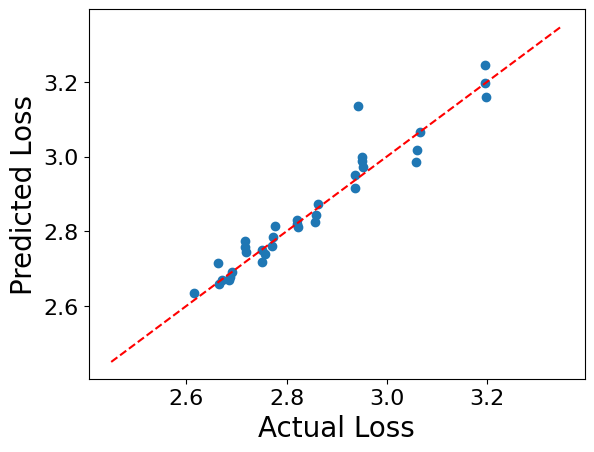

In [15]:
import matplotlib.pyplot as plt

plt.scatter(predict_loss, actual_loss,label='Fitted')
# plt.grid()
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel(r'Actual Loss',fontsize=20)
plt.ylabel(r'Predicted Loss',fontsize=20)
# plt.legend(loc="best", pop={'size': 14}, title_fontsize=16)
plt.plot([2.45, 3.35],[2.45, 3.35], color='red', linestyle='--', label='Ideal Fit')
plt.show()